## **Project Title: Cardiovascular Prediction**


**Group Members:**
1. Loo Ling Yan 23094683
2. Chu Jing Han 23116920
3. Hau Jia Qi    17204762
4. Loh Jing Wei 23118574
5. Goh Wee Ken   23118928

## **1. Project Introduction**

Cardiovascular diseases (CVD) are among the major causes of death globally, providing a huge challenge to public health systems and personal well-being. Early detection and intervention are crucial for minimizing the effect of these diseases, as they allow for preventative interventions, better risk factor management, and better patient outcomes.



*   **Objectives**
1. To increase early detection of cardiovascular disease in individuals by using machine learning predictive models
2. To assist healthcare providers in prioritizing early interventions and improving patient outcomes by reducing the likelihood of severe cardiovascular events

*   **Data Mining Goals**

Develop models with strong predictive performance to predict the presence of cardiovascular disease based on demographic, clinical, and lifestyle-related features.



## **2. Project Execution**

In [ ]:
from scipy.stats import zscore
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [ ]:
# import csv as dataframe using pandas
df = pd.read_csv('cardio_train.csv', sep=';')

In [ ]:
# Broad overview
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


## Data Exploration

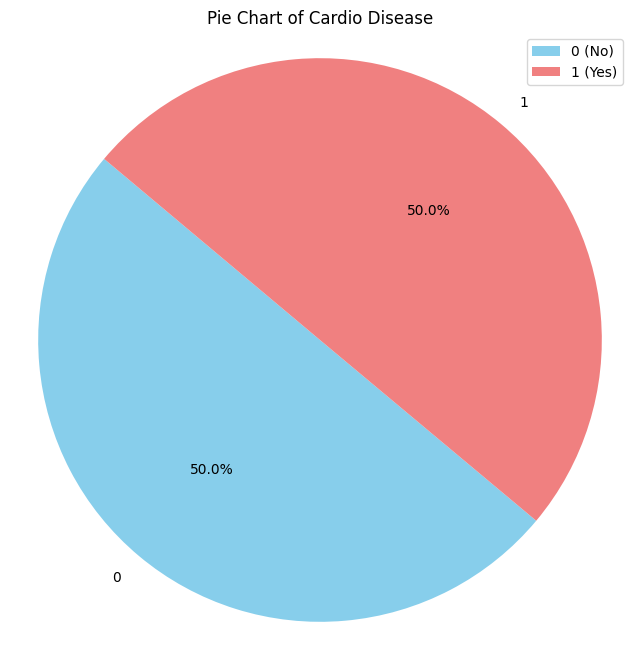

In [ ]:
# create pie chart

# Calculate the distribution of values
value_counts = df['cardio'].value_counts()

# Create a pie chart
plt.figure(figsize=(8, 8))
plt.pie(value_counts, labels=value_counts.index, autopct='%1.1f%%', startangle=140, colors=['skyblue', 'lightcoral'])

# Add a legend
plt.legend(['0 (No)', '1 (Yes)'], loc='upper right')

# Customize the plot
plt.title('Pie Chart of Cardio Disease')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

# Display the plot
plt.show()


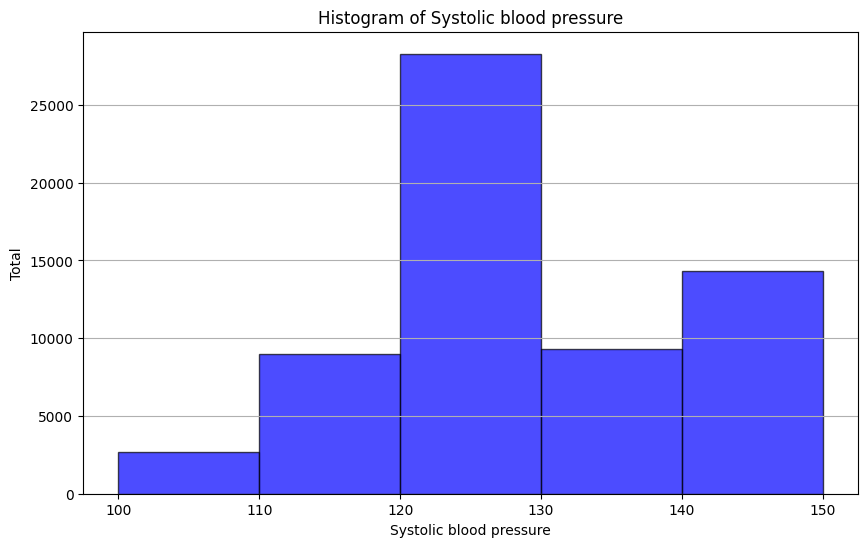

In [ ]:
# Specify the minimum and maximum values for the histogram range
min_value = 100
max_value = 150

# Create a histogram
plt.figure(figsize=(10, 6))
plt.hist(df['ap_hi'], bins=5, range=(min_value, max_value), color='blue', edgecolor='black', alpha=0.7)

# Customize the plot
plt.title('Histogram of Systolic blood pressure')
plt.xlabel('Systolic blood pressure')
plt.ylabel('Total')
plt.grid(True, axis='y')

# Display the plot
plt.show()

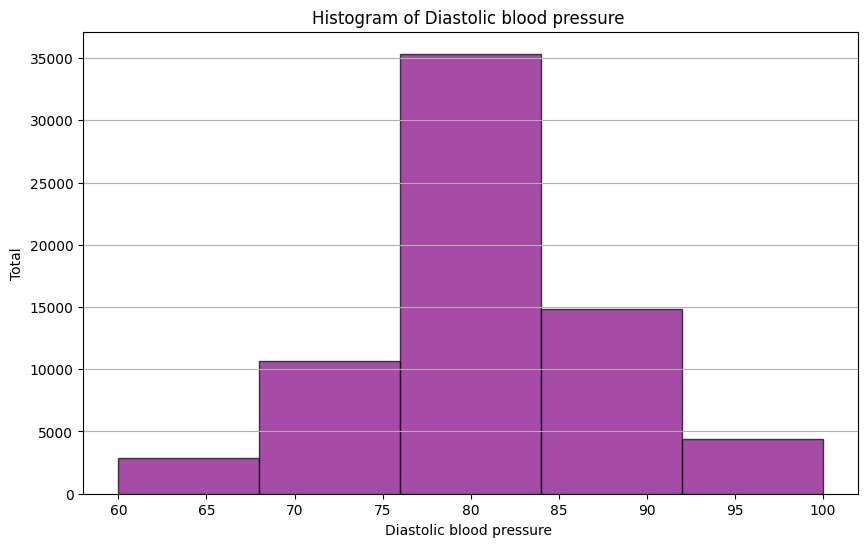

In [ ]:
# Specify the minimum and maximum values for the histogram range
min_value = 60
max_value = 100

# Create a histogram
plt.figure(figsize=(10, 6))
plt.hist(df['ap_lo'], bins=5, range=(min_value, max_value), color='Purple', edgecolor='black', alpha=0.7)

# Customize the plot
plt.title('Histogram of Diastolic blood pressure ')
plt.xlabel('Diastolic blood pressure ')
plt.ylabel('Total')
plt.grid(True, axis='y')

# Display the plot
plt.show()

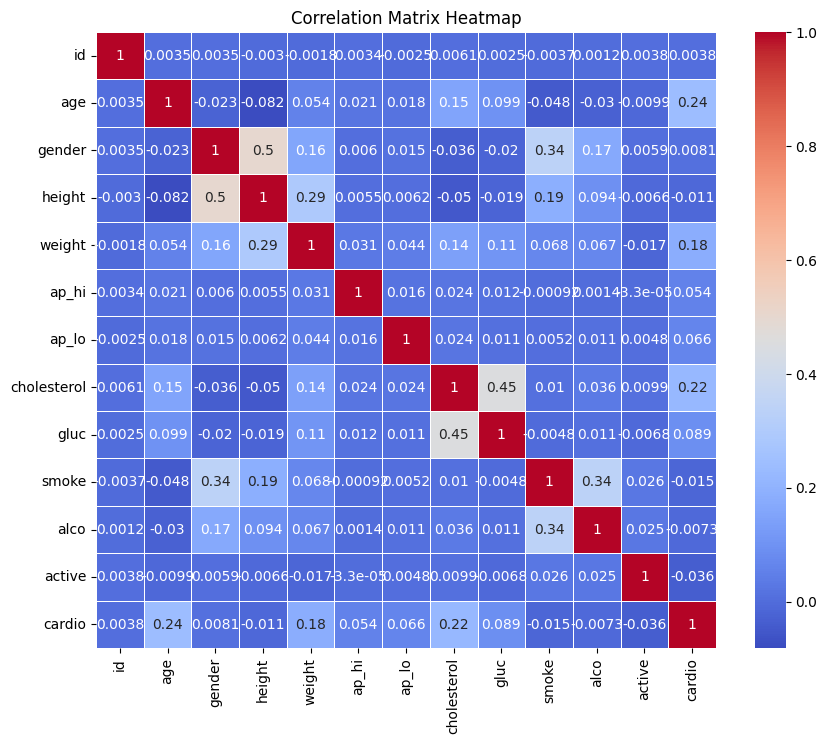

In [ ]:
# Correlation Matrix to check relationship between each parameter
corr_matrix = df.corr()

# Create a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)

# Customize the heatmap
plt.title('Correlation Matrix Heatmap')
plt.show()

Based on the correlation matrix heatmap, among all the dataset, the three highest correlation between cardiovascular disease are age (0.24), cholesterol (0.22), follow by weight (0.18).

<ipython-input-8-8c709438d387>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cardio', y='age', data=df, palette='coolwarm')


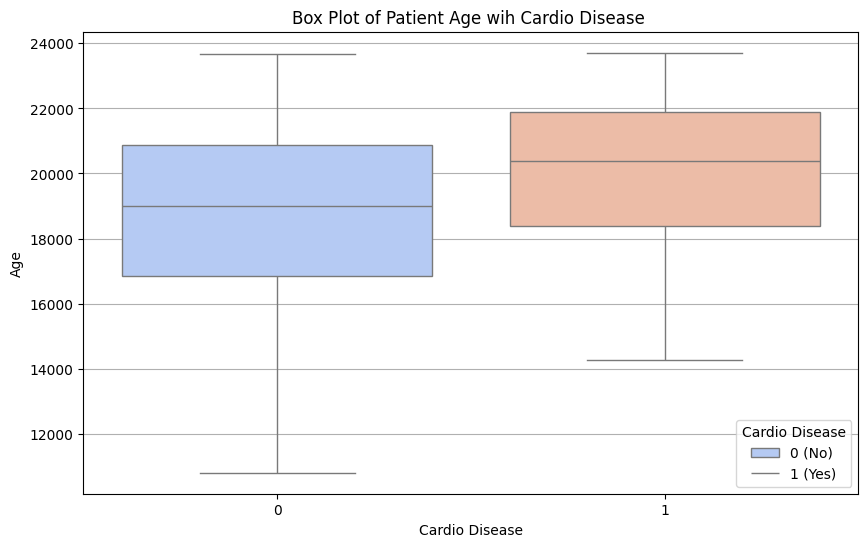

In [ ]:
# create box plot graph for age and cardio disease
plt.figure(figsize=(10, 6))
sns.boxplot(x='cardio', y='age', data=df, palette='coolwarm')

# Customize the plot
plt.title('Box Plot of Patient Age wih Cardio Disease ')
plt.xlabel('Cardio Disease')
plt.ylabel('Age')
plt.legend(title='Cardio Disease', labels=['0 (No)', '1 (Yes)'])
plt.grid(True, axis='y')

# Display the plot
plt.show()


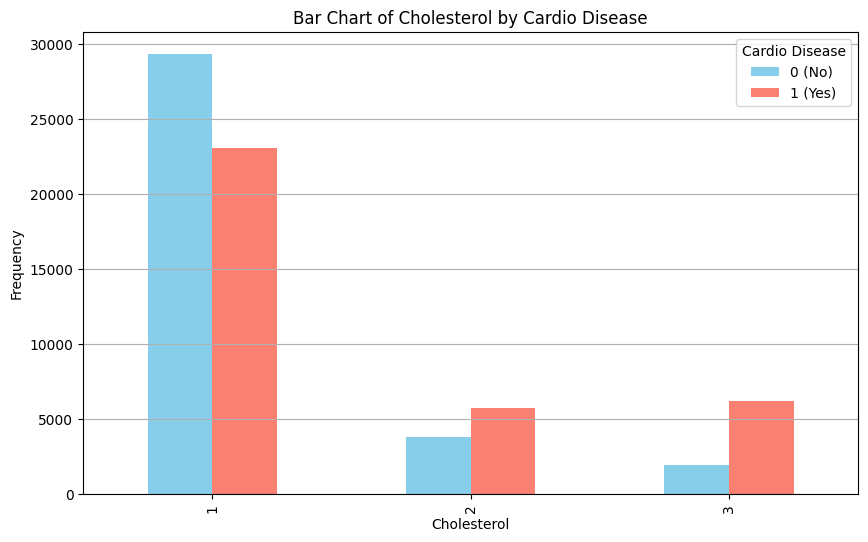

In [ ]:
# Create Bar Chart for cholesterol and cardio dieases

count_data = df.groupby(['cholesterol', 'cardio']).size().unstack()

# Create a bar chart
count_data.plot(kind='bar', stacked=False, figsize=(10, 6), color=['skyblue', 'salmon'])

# Customize the chart
plt.title('Bar Chart of Cholesterol by Cardio Disease')
plt.xlabel('Cholesterol')
plt.ylabel('Frequency')
plt.legend(title='Cardio Disease', labels=['0 (No)', '1 (Yes)'])
plt.grid(axis='y')

# Display the chart
plt.show()


Cholesterol group 1 indicates normal cholesterol level, but from the bar chat it can be observed that high numbers of patient with normal cholesterol has high frequency in getting cardiovascular disease as well.

<ipython-input-10-c5e1ae479e1f>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cardio', y='weight', data=df, palette='viridis')


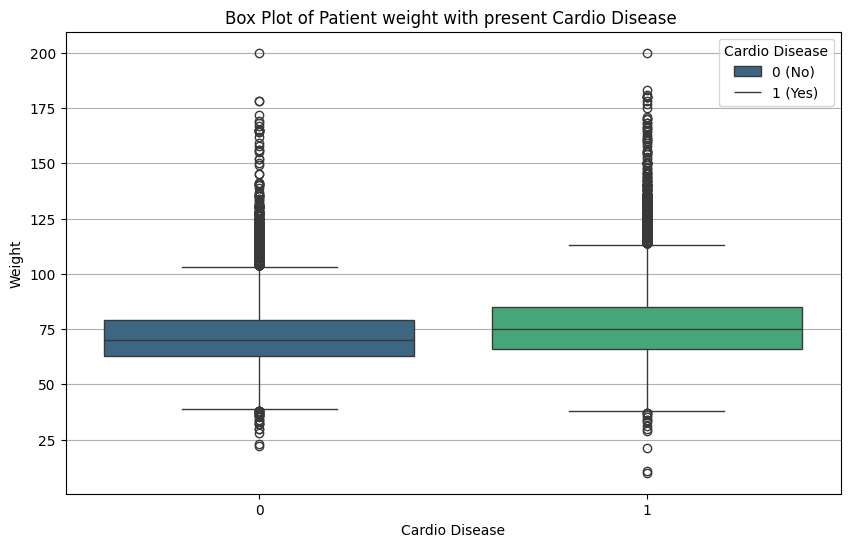

In [ ]:
# create box plot graph for weight and cardio disease
plt.figure(figsize=(10, 6))
sns.boxplot(x='cardio', y='weight', data=df, palette='viridis')

# Customize the plot
plt.title('Box Plot of Patient weight with present Cardio Disease ')
plt.xlabel('Cardio Disease')
plt.ylabel('Weight')
plt.legend(title='Cardio Disease', labels=['0 (No)', '1 (Yes)'])
plt.grid(True, axis='y')

# Display the plot
plt.show()

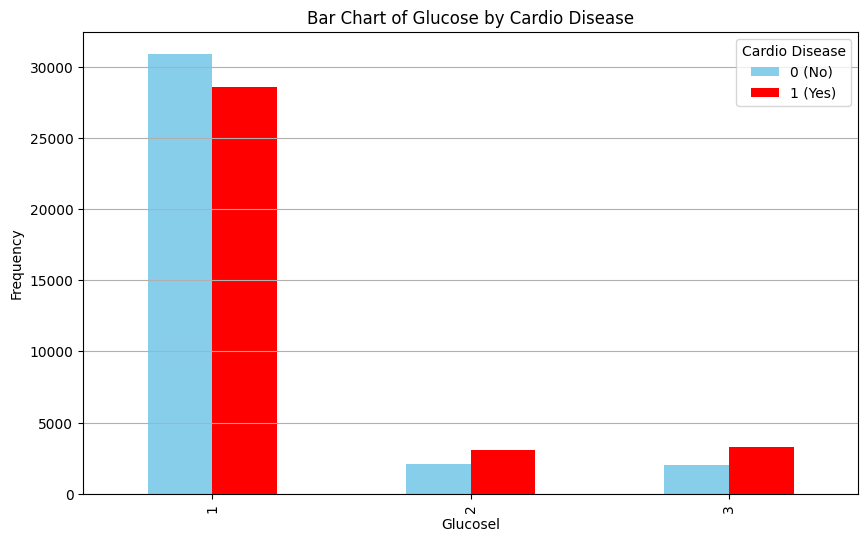

In [ ]:
# Create Bar Chart for Glucose and cardio dieases

count_data = df.groupby(['gluc', 'cardio']).size().unstack()

# Create a bar chart
count_data.plot(kind='bar', stacked=False, figsize=(10, 6), color=['skyblue', 'red'])

# Customize the chart
plt.title('Bar Chart of Glucose by Cardio Disease')
plt.xlabel('Glucosel')
plt.ylabel('Frequency')
plt.legend(title='Cardio Disease', labels=['0 (No)', '1 (Yes)'])
plt.grid(axis='y')

# Display the chart
plt.show()

### Statistical Analysis

Statistical test were conducted to assess the dependency between features and the target variable

#### two-sample independent t-test
A two-sample independent t-test was conducted for continuous features.
The results showed significant differences in the mean values of all continuous features between the two target groups (with and without cardiovascular disease), indicating that these features may be relevant in predicting the presence of cardiovascular disease.






In [ ]:
from scipy.stats import ttest_ind

# Numerical Columns
numerical_columns = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']

for feature in numerical_columns:
    group_0 = df[df['cardio'] == 0][feature]
    group_1 = df[df['cardio'] == 1][feature]

    # Ensure equal sample sizes for comparison
    min_length = min(len(group_0), len(group_1))
    group_0 = group_0.sample(n=min_length, random_state=42)
    group_1 = group_1.sample(n=min_length, random_state=42)

    # Perform t-test
    t, p = ttest_ind(group_0, group_1)
    print(f'Feature: {feature}')
    print('t-statistic: ', t)
    print('p-value: ', p)
    if p < 0.05:
        print('p-value is less than 0.05, reject null hypothesis')
        print(f'Conclusion: There is a significant difference in mean between {feature} for cardio = 0 and cardio = 1\n')
    else:
        print('p-value is greater than 0.05, fail to reject null hypothesis')
        print(f'Conclusion: There is no significant difference in mean between {feature} for cardio = 0 and cardio = 1\n')


Feature: age
t-statistic:  -64.88975358402966
p-value:  0.0
p-value is less than 0.05, reject null hypothesis
Conclusion: There is a significant difference in mean between age for cardio = 0 and cardio = 1

Feature: height
t-statistic:  2.91462710963597
p-value:  0.0035622660526046707
p-value is less than 0.05, reject null hypothesis
Conclusion: There is a significant difference in mean between height for cardio = 0 and cardio = 1

Feature: weight
t-statistic:  -48.80717185731365
p-value:  0.0
p-value is less than 0.05, reject null hypothesis
Conclusion: There is a significant difference in mean between weight for cardio = 0 and cardio = 1

Feature: ap_hi
t-statistic:  -14.43290874532821
p-value:  3.7556914669720317e-47
p-value is less than 0.05, reject null hypothesis
Conclusion: There is a significant difference in mean between ap_hi for cardio = 0 and cardio = 1

Feature: ap_lo
t-statistic:  -17.41142967776896
p-value:  9.396195686709588e-68
p-value is less than 0.05, reject null hy

#### Chi-Square test
A Chi-Square test was conducted for categorical features. The results indicate that all features, except for alcohol consumption, are significantly associated with the target variable.

In [ ]:
from scipy.stats import chi2_contingency

# Categorical Features
categorical_features = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']

for feature in categorical_features:
    contingency_table = pd.crosstab(df[feature], df['cardio'])

    # Perform Chi-Square Test
    chi2, p, dof, expctd = chi2_contingency(contingency_table.values)
    print(f'Feature: {feature}')
    print('Chi2 value: ', chi2)
    print('p-value: ', p)
    print('Degrees of Freedom (dof): ', dof)
    if p < 0.05:
        print('p-value is less than 0.05, reject null hypothesis')
        print(f'Conclusion: {feature} and cardio are NOT independent (there is a significant relationship)\n')
    else:
        print('p-value is greater than 0.05, fail to reject null hypothesis')
        print(f'Conclusion: {feature} and cardio are independent (no significant relationship)\n')


Feature: gender
Chi2 value:  4.569519103869497
p-value:  0.03254570031936317
Degrees of Freedom (dof):  1
p-value is less than 0.05, reject null hypothesis
Conclusion: gender and cardio are NOT independent (there is a significant relationship)

Feature: cholesterol
Chi2 value:  3423.4388976841265
p-value:  0.0
Degrees of Freedom (dof):  2
p-value is less than 0.05, reject null hypothesis
Conclusion: cholesterol and cardio are NOT independent (there is a significant relationship)

Feature: gluc
Chi2 value:  586.911808717551
p-value:  3.5786568357289105e-128
Degrees of Freedom (dof):  2
p-value is less than 0.05, reject null hypothesis
Conclusion: gluc and cardio are NOT independent (there is a significant relationship)

Feature: smoke
Chi2 value:  16.677916738748436
p-value:  4.4293623605077656e-05
Degrees of Freedom (dof):  1
p-value is less than 0.05, reject null hypothesis
Conclusion: smoke and cardio are NOT independent (there is a significant relationship)

Feature: alco
Chi2 value

However, since tree-based models evaluate feature importance during training, automatically identifying the most relevant predictors, no features were dropped.

# Data Preprocessing

'id' column is dropped because it is not a feature that contributes to the prediction task

In [ ]:
df = df.drop(columns=['id'])

## Missing Values

Using Python's isnull() function, we confirmed that no missing values were present in any of the columns

In [ ]:
print(df.isnull().sum())

age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64


## Datatype Inspection

To use Decision Tree, Random Forest, and Boosting for classification, the data types of each variable should align with the requirements of these machine learning models. For example, ordinal variables (cholesterol, gluc) as integer-encoded values (1, 2, 3)




In [ ]:
# Data type
print(df.dtypes)

id               int64
age              int64
gender           int64
height           int64
weight         float64
ap_hi            int64
ap_lo            int64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
cardio           int64
dtype: object


Since the data types are correct, no changes were made to the data types of the features.

## Split into Training and Testing Dataset

**Split df into training and testing dataset**

The dataset is split into 70% training and 30% testing dataset

In [ ]:
# Prepare the data
X = df.drop(columns=['cardio'])  # Features (drop the target column)
y = df['cardio']                # Target variable

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

Inspect X_train, y_train

In [ ]:
X_train.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active
68681,98125,20417,1,160,64.0,120,90,3,1,0,0,1
19961,28510,22690,2,167,65.0,120,80,3,3,0,0,0
11040,15795,22784,1,160,66.0,120,90,1,1,0,0,1
27673,39560,22648,1,163,55.0,125,90,3,1,0,0,1
22876,32677,21712,1,158,85.0,150,80,3,1,0,0,1


In [ ]:
y_train.head()

,cardio
68681,1
19961,0
11040,1
27673,1
22876,1


Inspect X_train, y_test

In [ ]:
X_test.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active
46730,66728,21770,1,156,64.0,140,80,2,1,0,0,1
48393,69098,21876,1,170,85.0,160,90,1,1,0,0,1
41416,59185,23270,1,151,90.0,130,80,1,1,0,0,1
34506,49288,19741,1,159,97.0,120,80,1,1,0,0,1
43725,62481,18395,1,164,68.0,120,80,1,1,0,0,1


In [ ]:
y_test.head()

,cardio
46730,1
48393,1
41416,1
34506,1
43725,0


In [ ]:
print("Number of rows for full dataset:", df.shape[0])
print("Number of rows for training dataset:", X_train.shape[0])
print("Number of rows for testing dataset:", X_test.shape[0])

Number of rows for full dataset: 70000
Number of rows for training dataset: 49000
Number of rows for testing dataset: 21000


## Outliers Removal


**Summary Statistics**

Since not all values outside the IQR range are necessarily outliers, we review the summary statistics to identify such values.

In [ ]:
X_train[numerical_columns].describe()

,age,height,weight,ap_hi,ap_lo
count,49000.000000,49000.000000,49000.000000,49000.000000,49000.000000
mean,19458.260612,164.351347,74.181439,128.893898,97.102347
std,2469.889709,8.196510,14.377289,158.084444,200.210646
min,10798.000000,55.000000,22.000000,-140.000000,0.000000
25%,17655.750000,159.000000,65.000000,120.000000,80.000000
50%,19695.000000,165.000000,72.000000,120.000000,80.000000
75%,21322.000000,170.000000,82.000000,140.000000,90.000000
max,23713.000000,250.000000,200.000000,14020.000000,11000.000000




By checking the minimum and maximum values, it can be observed that variables such as *height, weight, systolic blood pressure, and diastolic blood pressure* contain unrealistic values.

**Remove outliers using the IQR method**

In [ ]:
# Define function to remove outliers using IQR method
def remove_outliers_iqr(df, columns):
    """
    Removes rows with outliers based on the IQR method for the specified columns.
    """
    for column in columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        # Filter rows within the bounds for the current column
        df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df

In [ ]:
# Define columns with outliers
outliers_column = ['height', 'weight', 'ap_hi', 'ap_lo']

Outliers are removed only from the training data to prevent data leakage and ensure the test set remains representative of real-world, unseen data.

In [ ]:
X_train = remove_outliers_iqr(X_train, outliers_column)

# Remove corresponding rows from y_train to maintain consistency
y_train = y_train.loc[X_train.index]

In [ ]:
X_train[numerical_columns].describe()

,age,height,weight,ap_hi,ap_lo
count,43779.000000,43779.000000,43779.000000,43779.000000,43779.000000
mean,19478.574225,164.387949,73.177713,126.321113,81.676055
std,2461.734260,7.538257,12.265185,14.274634,7.662963
min,10859.000000,143.000000,40.000000,90.000000,65.000000
25%,17695.000000,159.000000,65.000000,120.000000,80.000000
50%,19708.000000,165.000000,72.000000,120.000000,80.000000
75%,21333.000000,170.000000,81.000000,140.000000,90.000000
max,23713.000000,186.000000,107.000000,170.000000,105.000000


## Data Transformation

**Convert Age column from days to years**

In [ ]:
# Transform age in both train and test sets
X_train['age'] = (X_train['age'] / 365).round()
X_test['age'] = (X_test['age'] / 365).round()

Export X_train to clean dataset

In [ ]:
X_train.to_csv("cardio_clean.csv", index=False)


**Apply Z-score normalization to numerical columns**

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Fit the scaler on training data and transform both train and test sets
X_train[numerical_columns] = scaler.fit_transform(X_train[numerical_columns]) # fit and transform training data
X_test[numerical_columns] = scaler.transform(X_test[numerical_columns]) # transform testing data

Save the scaler

In [ ]:
import joblib

# Save the scaler to a file
joblib.dump(scaler, "scaler.joblib")
print("Scaler saved as scaler.joblib")

Scaler saved as scaler.joblib


Inspect the mean and standard deviation of each columns to verify the transformed dataset has mean ~0 and std ~1

In [ ]:
# Verify that the transformed training data has mean ~0 and std ~1
print("\nMean of scaled X_train:")
print(X_train[numerical_columns].mean())

print("\nStandard deviation of scaled X_train:")
print(X_train[numerical_columns].std())


Mean of scaled X_train:
age      -3.489497e-17
height    8.650706e-16
weight    5.039483e-16
ap_hi    -4.787914e-16
ap_lo     6.654390e-17
dtype: float64

Standard deviation of scaled X_train:
age       1.000011
height    1.000011
weight    1.000011
ap_hi     1.000011
ap_lo     1.000011
dtype: float64


In [ ]:
# Verify that the transformed testing data has mean ~0 and std ~1
print("\nMean of scaled X_test (should not be 0 since it's scaled using training stats):")
print(X_test[numerical_columns].mean())

print("\nStandard deviation of scaled X_test (should not be 1 for the same reason):")
print(X_test[numerical_columns].std())


Mean of scaled X_test (should not be 0 since it's scaled using training stats):
age       0.005981
height   -0.001370
weight    0.088427
ap_hi     0.162347
ap_lo     1.807831
dtype: float64

Standard deviation of scaled X_test (should not be 1 for the same reason):
age        0.999368
height     1.093365
weight     1.177243
ap_hi     10.092426
ap_lo     20.582496
dtype: float64


# **Machine Learning Model**


The selected machine learning models including **Decision Tree**, **Random Forest** and **XGBoost**.

## Machine Learning Model 1: Decision Tree

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# Initialize Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(max_depth=5, random_state=42)

# Train the classifier
dt_classifier.fit(X_train, y_train)

# Predict on the test set
y_pred = dt_classifier.predict(X_test)

# Accuracy
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:')
print(cm)

# Extract confusion matrix values
TN, FP, FN, TP = cm[0][0], cm[0][1], cm[1][0], cm[1][1]

# Calculate specificity
specificity = TN / (TN + FP)
print(f"Specificity: {specificity:.2f}")

# Calculate sensitivity
sensitivity = TP / (TP + FN)
print(f"Sensitivity: {sensitivity:.4f}")

# Classification report
print('Classification Report:')
print(classification_report(y_test, y_pred))


Accuracy: 0.7187
Confusion Matrix:
[[8744 1717]
 [4191 6348]]
Specificity: 0.84
Sensitivity: 0.6023
Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.84      0.75     10461
           1       0.79      0.60      0.68     10539

    accuracy                           0.72     21000
   macro avg       0.73      0.72      0.71     21000
weighted avg       0.73      0.72      0.71     21000



## Machine Learning Model 2: Random Forest

Parameters used to configure Random Forest classifier:
*   max_depth=10: Limits the maximum depth of each tree to 10 to prevent overfitting.
*   max_features='sqrt': Uses the square root of the number of features when looking for the best split.
*   min_samples_leaf=2: Requires at least 2 samples in a leaf node.
*   min_samples_split=10: Requires at least 10 samples to split an internal node.
*   n_estimators=300: Uses 300 trees in the forest.
*   random_state=42: Ensures reproducibility.





In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Train the model with best parameters
best_rf_model = RandomForestClassifier(
    max_depth=10,
    max_features='sqrt',
    min_samples_leaf=2,
    min_samples_split=10,
    n_estimators=300,
    random_state=42
)

best_rf_model.fit(X_train, y_train)

# Make predictions
y_pred = best_rf_model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Extract confusion matrix values
TN, FP, FN, TP = cm[0][0], cm[0][1], cm[1][0], cm[1][1]

# Calculate specificity
specificity = TN / (TN + FP)
print(f"Specificity: {specificity:.4f}")

# Calculate sensitivity
sensitivity = TP / (TP + FN)
print(f"Sensitivity: {sensitivity:.4f}")

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.7376
Confusion Matrix:
[[8337 2124]
 [3387 7152]]
Specificity: 0.7970
Sensitivity: 0.6786
Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.80      0.75     10461
           1       0.77      0.68      0.72     10539

    accuracy                           0.74     21000
   macro avg       0.74      0.74      0.74     21000
weighted avg       0.74      0.74      0.74     21000



## Machine Learning Model 3: XGBoost

Parameters below are used to configure the XGBoost classifier:
*   alpha=1: L1 regularization term on weights.
*   colsample_bytree=0.8: Fraction of features to be used for each tree.
*   gamma=0: Minimum loss reduction required to make a further partition.
*   reg_lambda=3: L2 regularization term on weights.
*   learning_rate=0.01: Step size shrinkage to prevent overfitting.
*   max_depth=7: Maximum depth of a tree.
*   n_estimators=500: Number of boosting rounds.
*   subsample=0.7: Fraction of samples to be used for each tree.
*   eval_metric='logloss': Evaluation metric for validation data.
*   random_state=42: Ensures reproducibility.





In [ ]:
import warnings
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Suppress warnings
warnings.filterwarnings("ignore", category=UserWarning)

# Define the model with the best parameters
xgb_model = XGBClassifier(
    alpha=1,
    colsample_bytree=0.8,
    gamma=0,
    reg_lambda=3,  # Use 'reg_lambda' instead of 'lambda_' to avoid the warning
    learning_rate=0.01,
    max_depth=7,
    n_estimators=500,
    subsample=0.7,
    eval_metric='logloss',
    random_state=42
)

# Fit the model on the training data
xgb_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = xgb_model.predict(X_test)

# Evaluate the model
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Extract confusion matrix values
TN, FP, FN, TP = cm[0][0], cm[0][1], cm[1][0], cm[1][1]

# Calculate specificity
specificity = TN / (TN + FP)
print(f"Specificity: {specificity:.4f}")

# Calculate sensitivity
sensitivity = TP / (TP + FN)
print(f"Sensitivity: {sensitivity:.4f}")

# Classification Report
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.7391
Confusion Matrix:
 [[8193 2268]
 [3210 7329]]
Specificity: 0.7832
Sensitivity: 0.6954
Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.78      0.75     10461
           1       0.76      0.70      0.73     10539

    accuracy                           0.74     21000
   macro avg       0.74      0.74      0.74     21000
weighted avg       0.74      0.74      0.74     21000



In [ ]:
import joblib

# Save the model
joblib.dump(xgb_model, "xgb_model.joblib")
print("Model saved as xgb_model.joblib")

Model saved as xgb_model.joblib


# Evaluation Metric - ROC-AUC Score

Decision Tree ROC-AUC Score: 0.7902
Random Forest ROC-AUC Score: 0.8025
XGBoost ROC-AUC Score: 0.8031


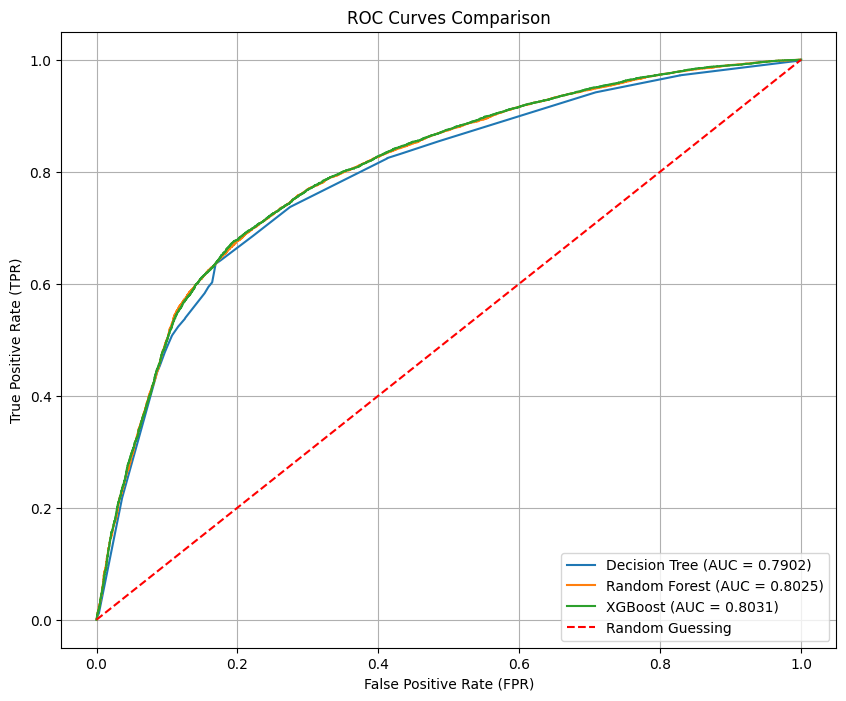

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Initialize a dictionary to store results
roc_results = {}

# Function to calculate and store ROC-AUC results
def calculate_roc_auc(model, X_test, y_test, model_name):
    y_prob = model.predict_proba(X_test)[:, 1]  # Predicted probabilities
    roc_auc = roc_auc_score(y_test, y_prob)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_results[model_name] = (fpr, tpr, roc_auc)
    print(f"{model_name} ROC-AUC Score: {roc_auc:.4f}")

# Calculate ROC-AUC for each model
calculate_roc_auc(dt_classifier, X_test, y_test, "Decision Tree")
calculate_roc_auc(best_rf_model, X_test, y_test, "Random Forest")
calculate_roc_auc(xgb_model, X_test, y_test, "XGBoost")

# Plot all ROC curves on one graph
plt.figure(figsize=(10, 8))
for model_name, (fpr, tpr, roc_auc) in roc_results.items():
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {roc_auc:.4f})")

plt.plot([0, 1], [0, 1], color="red", linestyle="--", label="Random Guessing")  # Diagonal line
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curves Comparison")
plt.legend(loc="lower right")
plt.grid()
plt.show()


The ROC curves compare the performance of three machine learning models. The AUC value measures the accuracy of the model. According to the plotted ROC curves, XGBoost has the highest AUC (0.8031), followed by the Random Forest (0.8025) and Decision Tree (0.7902). The red dashed reference line represents a model that makes random predictions, with an AUC of 0.5.
All models significantly outperform random guessing, indicating meaningful predictive power. In short, XGBoost would likely be the recommended model with the highest AUC of 0.8031.

# Deployment (Data Product)

In [ ]:
pip install gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 MB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 320.4/320.4 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.8/94.8 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 66.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.2/73.2 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 3.2 MB/s eta 0:00:00
  Attempting uninstall: markupsafe
    Found existing installation: MarkupSafe 3.0.2
    Uninstalling MarkupSafe-3.0.2:
      Successfully uninstalled MarkupSafe-3.0.2


In [ ]:
import gradio as gr
import xgboost as xgb
import numpy as np
from sklearn.preprocessing import StandardScaler
import joblib

# Load the XGBoost model
xgb_model = joblib.load("xgb_model.joblib")

# Load the scaler
scaler = joblib.load("scaler.joblib")


def predict_cardiac_disease(age, gender, height, weight, ap_hi, ap_lo, cholesterol, gluc, smoke, alco, active):
    try:
        # Convert inputs to correct types
        age = int(age)
        gender = int(gender)  # Expecting 1 (Female) or 2 (Male)
        height = int(height)
        weight = float(weight)
        ap_hi = int(ap_hi)
        ap_lo = int(ap_lo)
        cholesterol = int(cholesterol)  # Expecting 1, 2, 3
        gluc = int(gluc)                # Expecting 1, 2, 3
        smoke = int(smoke)              # Expecting 0 or 1
        alco = int(alco)                # Expecting 0 or 1
        active = int(active)            # Expecting 0 or 1

        # Prepare numerical features for scaling
        numerical_features = np.array([[age, height, weight, ap_hi, ap_lo]])
        scaled_features = scaler.transform(numerical_features)  # Scale numerical features only

        # Combine scaled numerical features with categorical features in the correct order
        full_input = np.array([[scaled_features[0, 0],  # Scaled age
                                gender,
                                scaled_features[0, 1],  # Scaled height
                                scaled_features[0, 2],  # Scaled weight
                                scaled_features[0, 3],  # Scaled ap_hi
                                scaled_features[0, 4],  # Scaled ap_lo
                                cholesterol,
                                gluc,
                                smoke,
                                alco,
                                active]])

        # Debugging: Log the prepared input
        print(f"Prepared input features: {full_input.tolist()}")

        # Predict probabilities using the model
        probabilities = xgb_model.predict_proba(full_input)
        probability = probabilities[0, 1]   # Take the first probability for class 1

        # Adjust threshold for classification
        threshold = 0.5
        risk = "High Risk" if probability >= threshold else "Low Risk"

        # Include debug information
        return f"{probability:.4f}", risk
    except Exception as e:
        return f"Error: {e}", "Error"

# Define the Gradio interface
demo = gr.Interface(
    fn=predict_cardiac_disease,
    inputs=[
        gr.Number(label="Age (years)"),
        gr.Radio(["Female (1)", "Male (2)"], type="index", label="Gender"),  # 1: Female, 2: Male
        gr.Number(label="Height (cm)"),
        gr.Number(label="Weight (kg)"),
        gr.Number(label="Systolic Blood Pressure (ap_hi)"),
        gr.Number(label="Diastolic Blood Pressure (ap_lo)"),
        gr.Radio(["Normal (1)", "Above Normal (2)", "Well Above Normal (3)"], type="index", label="Cholesterol"),
        gr.Radio(["Normal (1)", "Above Normal (2)", "Well Above Normal (3)"], type="index", label="Glucose"),
        gr.Radio(["No (0)", "Yes (1)"], type="index", label="Smoking"),
        gr.Radio(["No (0)", "Yes (1)"], type="index", label="Alcohol Intake"),
        gr.Radio(["Inactive (0)", "Active (1)"], type="index", label="Physical Activity"),
    ],
    outputs=[
        gr.Textbox(label="Probability of Cardiac Disease"),  # Box for probabilities
        gr.Textbox(label="Risk Level"),  # Box for High/Low Risk
    ],
    title="Cardiac Disease Prediction",
    description="Enter your health details to check the probability and risk level of cardiac disease.",
)

# Launch the app
demo.launch()


Running Gradio in a Colab notebook requires sharing enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://1c50d92f115d18196e.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
import gradio as gr
import xgboost as xgb
import numpy as np
import joblib

# Load the XGBoost model
xgb_model = joblib.load("xgb_model.joblib")

# Load the scaler
scaler = joblib.load("scaler.joblib")

# Path to the correlation plot
plot_file = "/content/correlation_with_cardio.png"

def predict_cardiac_disease(age, gender, height, weight, ap_hi, ap_lo, cholesterol, gluc, smoke, alco, active):
    try:
        # Convert inputs to correct types
        age = int(age)
        gender = int(gender)  # Expecting 1 (Female) or 2 (Male)
        height = int(height)
        weight = float(weight)
        ap_hi = int(ap_hi)
        ap_lo = int(ap_lo)
        cholesterol = int(cholesterol)  # Expecting 1, 2, 3
        gluc = int(gluc)                # Expecting 1, 2, 3
        smoke = int(smoke)              # Expecting 0 or 1
        alco = int(alco)                # Expecting 0 or 1
        active = int(active)            # Expecting 0 or 1

        # Prepare numerical features for scaling
        numerical_features = np.array([[age, height, weight, ap_hi, ap_lo]])
        scaled_features = scaler.transform(numerical_features)  # Scale numerical features only

        # Combine scaled numerical features with categorical features in the correct order
        full_input = np.array([[scaled_features[0, 0],  # Scaled age
                                gender,
                                scaled_features[0, 1],  # Scaled height
                                scaled_features[0, 2],  # Scaled weight
                                scaled_features[0, 3],  # Scaled ap_hi
                                scaled_features[0, 4],  # Scaled ap_lo
                                cholesterol,
                                gluc,
                                smoke,
                                alco,
                                active]])

        # Predict probabilities using the model
        probabilities = xgb_model.predict_proba(full_input)
        probability = probabilities[0, 1]   # Take the first probability for class 1

        # Adjust threshold for classification
        threshold = 0.5
        risk = "High Risk" if probability >= threshold else "Low Risk"

        return f"{probability:.4f}", risk
    except Exception as e:
        return f"Error: {e}", "Error"

# Define the Gradio interface
with gr.Blocks() as demo:
    gr.Markdown("# Cardiac Disease Prediction")
    gr.Markdown(
        "Enter your health details to check the probability and risk level of cardiac disease."
    )
    with gr.Row():
        with gr.Column(scale=3):  # Main input form on the left
            age = gr.Number(label="Age (years)")
            gender = gr.Radio(["Female (1)", "Male (2)"], type="index", label="Gender")
            height = gr.Number(label="Height (cm)")
            weight = gr.Number(label="Weight (kg)")
            ap_hi = gr.Number(label="Systolic Blood Pressure (ap_hi)")
            ap_lo = gr.Number(label="Diastolic Blood Pressure (ap_lo)")
            cholesterol = gr.Radio(
                ["Normal (1)", "Above Normal (2)", "Well Above Normal (3)"],
                type="index",
                label="Cholesterol",
            )
            gluc = gr.Radio(
                ["Normal (1)", "Above Normal (2)", "Well Above Normal (3)"],
                type="index",
                label="Glucose",
            )
            smoke = gr.Radio(["No (0)", "Yes (1)"], type="index", label="Smoking")
            alco = gr.Radio(["No (0)", "Yes (1)"], type="index", label="Alcohol Intake")
            active = gr.Radio(
                ["Inactive (0)", "Active (1)"], type="index", label="Physical Activity"
            )
            predict_button = gr.Button("Predict")
            output_probability = gr.Textbox(label="Probability of Cardiac Disease")
            output_risk = gr.Textbox(label="Risk Level")
        with gr.Column(scale=2):  # Correlation plot on the right
            gr.Image(value=plot_file, label="Feature Correlation with Cardio", height=200, width=400)

    # Connect prediction logic
    predict_button.click(
        predict_cardiac_disease,
        inputs=[age, gender, height, weight, ap_hi, ap_lo, cholesterol, gluc, smoke, alco, active],
        outputs=[output_probability, output_risk],
    )

# Launch the app
demo.launch()


Running Gradio in a Colab notebook requires sharing enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a646388b29cf088900.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
# Calculate correlation with the target variable 'cardio'
corr_with_target = df.corr()['cardio'].drop('cardio')  # Drop 'cardio' itself

# Create the bar chart
plt.figure(figsize=(10, 6))
corr_with_target.sort_values(ascending=False).plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Correlation with Cardio (Target Variable)', fontsize=16)
plt.ylabel('Correlation Coefficient', fontsize=14)
plt.xlabel('Features', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
# Save the plot to a file
plot_file = "correlation_with_cardio.png"
plt.savefig(plot_file)
plt.close()



KeyError: 'chol'

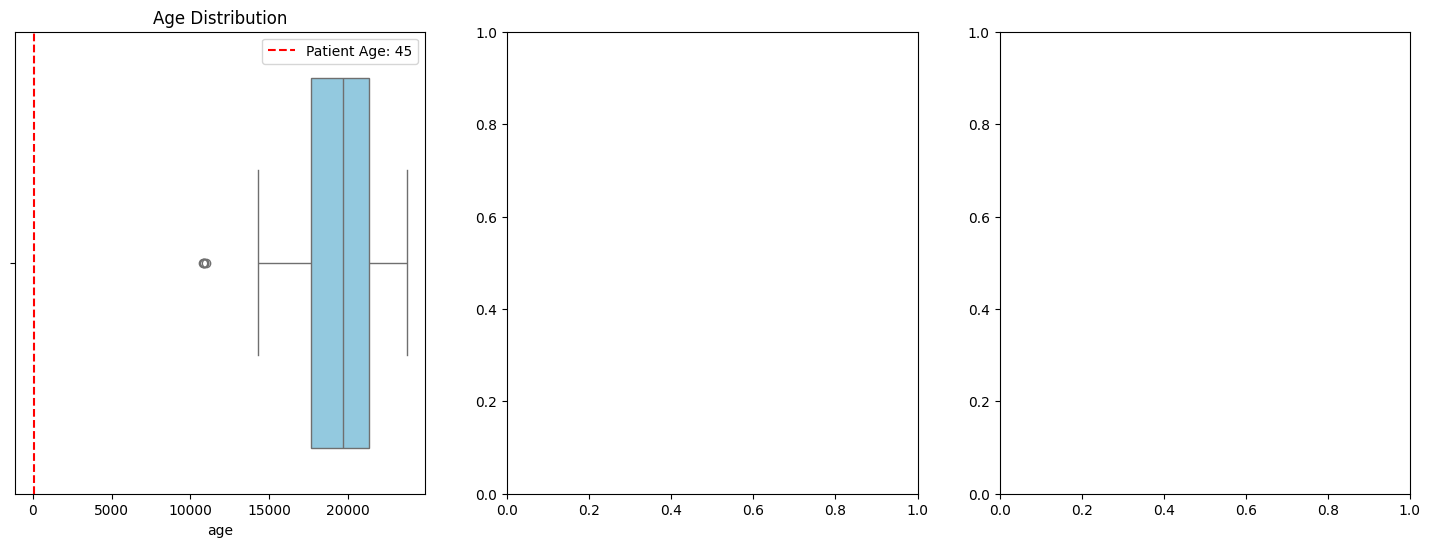

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_patient_features(patient_data, df):
    """
    Visualizes where a specific patient stands for 'age', 'chol', and 'weight'
    compared to the rest of the dataset.

    Args:
    - patient_data (dict): Patient's values, e.g., {"age": 45, "chol": 2, "weight": 70}
    - df (DataFrame): The dataset for comparison.
    """
    # Extract patient's features
    age = patient_data["age"]
    chol = patient_data["chol"]
    weight = patient_data["weight"]

    # Set up the subplots
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # 1. Age: Box Plot
    sns.boxplot(x=df['age'], ax=axes[0], color='skyblue')
    axes[0].axvline(x=age, color='red', linestyle='--', label=f"Patient Age: {age}")
    axes[0].set_title("Age Distribution")
    axes[0].legend()

    # 2. Chol: Bar Plot
    sns.countplot(x=df['chol'], ax=axes[1], palette="pastel")
    axes[1].bar(chol - 1, df['chol'].value_counts()[chol], color='red', label=f"Patient Chol: {chol}")
    axes[1].set_title("Cholesterol Category Distribution")
    axes[1].set_xlabel("Cholesterol Category")
    axes[1].set_ylabel("Count")
    axes[1].legend()

    # 3. Weight: Box Plot
    sns.boxplot(x=df['weight'], ax=axes[2], color='lightgreen')
    axes[2].axvline(x=weight, color='red', linestyle='--', label=f"Patient Weight: {weight}")
    axes[2].set_title("Weight Distribution")
    axes[2].legend()

    plt.tight_layout()
    plt.show()

# Example usage
# Patient's data
patient = {"age": 45, "chol": 2, "weight": 70}

# Assume 'df' is your dataset
plot_patient_features(patient, df)


# **Conclusion**

### **Model Performance Comparison**


All three models (Decision Tree, Random Forest, and XGBoost) exhibited comparable performance on the heart disease prediction task. XGBoost achieved the highest accuracy at 0.7391, followed closely by Random Forest (0.7376) and Decision Tree (0.7187). While these differences in accuracy are relatively small, it is suggested that XGBoost might have a slight edge in overall predictive power. Decision Tree demonstrated the highest specificity (0.8400), indicating its ability to accurately identify individuals without the disease. All models exhibited similar F1-scores, suggesting a good balance between precision and recall in their predictions. Additionally, the ROC curve with the AUC values supported that XGBoost has the highest accuracy at 0.8031, followed closely by Random Forest (0.8025) and Decision Tree (0.7902). The sensitivity of each models is the main metrics in indicating the model performance. Sensitivity, also known as the true positive rate, is a crucial metric in disease detection because it measures a model's ability to correctly identify individuals who have the disease. For example, failing to detect cardiac disease might delay necessary treatment, potentially leading to worsening health outcomes or even fatal consequences. XGBoost achieved the highest sensitivity with 0.6954, followed by Random Forest with 0.6786 and Decision Tree with 0.6023.

These findings indicate that while XGBoost might have a slight advantage in terms of overall accuracy, all three models offer viable options for cardiovascular disease prediction with varying strengths in terms of specificity.


### **Deployment**


*   Developing a simple web or mobile application for end-users to interact with the model and visualize prediction results.
*   Deployment in an environment where users (healthcare providers) can input patient data to get real-time predictions.



### **Future Work**


*   Incorporating additional patient information such as family history, lifestyle factors or genetic data for more personalized predictions.
*   Conducting clinical trials or collaborating with healthcare providers for real-world validation and fine-tuning.
*   Exploring data privacy, security concerns, and maintaining ethical standards while using medical data.



# Member's Contribution

1. Hau Jia Qi - CRISP-DM, Result Evaluation + Interpretation, Conclusion, Formatting
2. Chu Jing Han - CRISP-DM, Result Evaluation + Interpretation, Conclusion, Formatting
3. Loh Jing Wei - Statistical Analysis, Data Pre-processing
4. Loo Ling Yan - Exploratory Data Analysis
5. Goh Wee Ken - Machine Learning Modelling

